# 💀 2. Salud: Suicidio (RESULTADO MÁS GRAVE)

👉 Este análisis sirve para validar si los patrones de ideación escalan a hechos consumados de forma proporcional.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Carga de Datos Preprocesados

In [13]:
# Ruta robusta: funciona independiente del cwd de Jupyter
# Intenta relativo al cwd primero, luego usa ruta absoluta como fallback
_candidates = [
    Path('../../01_datos/processed'),
    Path('../../../01_datos/processed'),
    Path(r'C:/Users/Latitude/Documents/V Semestre/DATAJAM/DATAJAM-DATAFONO_2026/datajam-2026-bogota/01_datos/processed'),
]

PROCESSED_DIR = next((p for p in _candidates if p.exists()), None)
assert PROCESSED_DIR is not None, f'No se encontro el directorio processed. CWD={Path.cwd()}'

file_path = PROCESSED_DIR / 'p_salud_suicidio.csv'
df_suicidio = pd.read_csv(file_path)
print(f'Total de registros cargados: {len(df_suicidio):,}')
display(df_suicidio.head())

Total de registros cargados: 8,222


,ano_del_hecho,grupo_de_edad_quinquenal_,ciclo_vital,sexo_de_la_victima,estado_civil,escolaridad,pertenencia_grupal,razon_del_suicidio,mes_del_hecho,cod_localidad,localidad_del_hecho
0,2017,(10 a 14),(12 a 17) Adolescencia,Hombre,Soltero(a),Educación básica primaria,Ninguno,Enfermedad física o mental,Octubre,15,Antonio Nariño
1,2016,(15 a 17),(12 a 17) Adolescencia,Hombre,Soltero (a),Educación básica secundaria o secundaria baja,Ninguno,Sin información,Febrero,15,Antonio Nariño
2,2020,(15 a 17),(12 a 17) Adolescencia,Mujer,Soltero(a),Educación básica secundaria o secundaria baja,Ninguno,Sin información,Febrero,15,Antonio Nariño
3,2018,(15 a 17),(12 a 17) Adolescencia,Hombre,Soltero(a),Educación básica primaria,Otro,Enfermedad física o mental,Noviembre,15,Antonio Nariño
4,2025,(15 a 17),(12 a 17) Adolescencia,Mujer,Unión libre,Sin información,Sin información,Desamor,Marzo,15,Antonio Nariño


## 📈 Tendencia
**¿También está aumentando al igual que la ideación?**

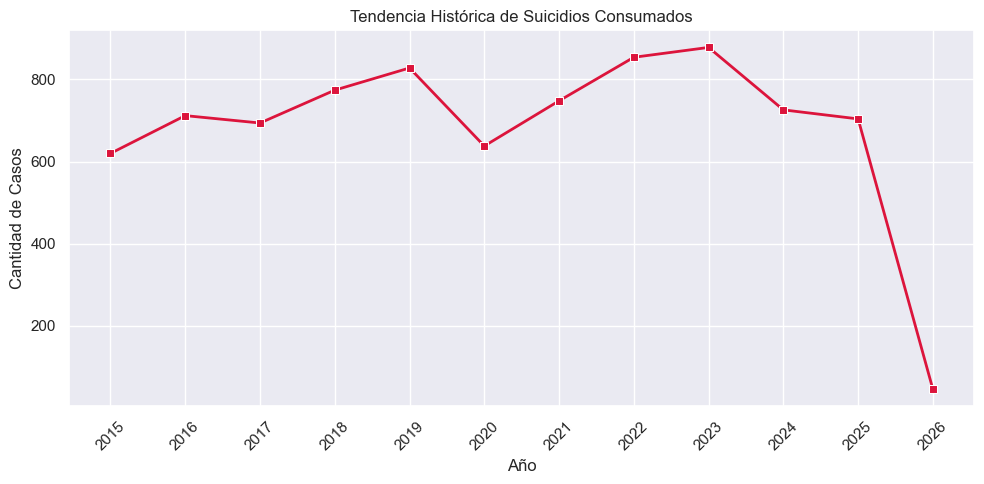

In [14]:
# ¿También está aumentando al igual que la ideación?
col_ano = 'ano_del_hecho'

tendencia = df_suicidio[col_ano].value_counts().sort_index()
plt.figure(figsize=(10,5))
sns.lineplot(x=tendencia.index, y=tendencia.values, marker='s', color='crimson', linewidth=2)
plt.title('Tendencia Histórica de Suicidios Consumados')
plt.xlabel('Año')
plt.ylabel('Cantidad de Casos')
plt.xticks(tendencia.index, rotation=45)
plt.tight_layout()
plt.show()

## 📍 Territorial
**¿Coincide con las mismas localidades de ideación?**

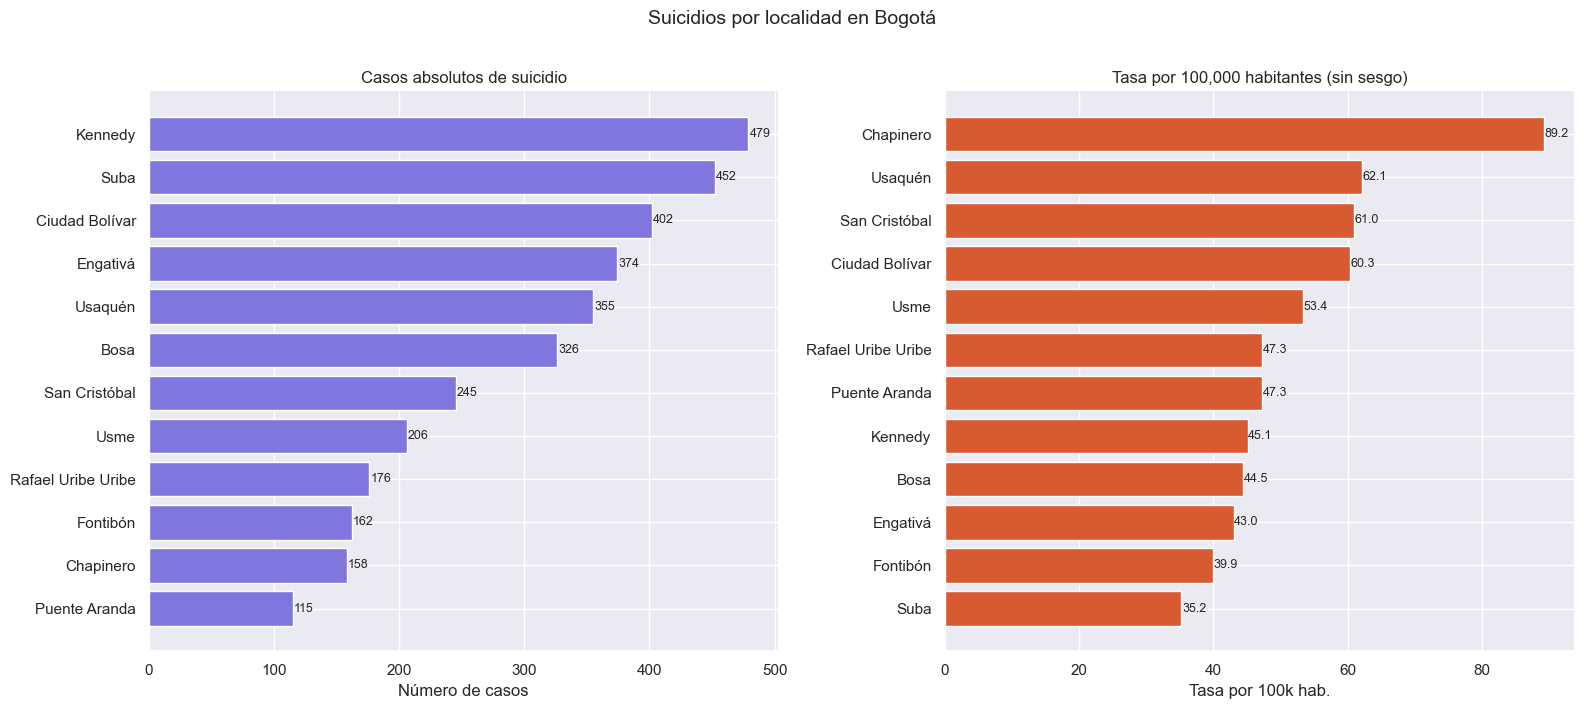

In [23]:
col_loc = 'localidad_del_hecho'

# Excluir Bogotá genérico y Localidad Desconocida
df_sui_limpio = df_suicidio[
    ~df_suicidio[col_loc].str.contains('Bogot|Desconocida', na=False, case=False)
]

conteo = df_sui_limpio[col_loc].value_counts().reset_index()
conteo.columns = ['localidad', 'casos']

def limpiar(s):
    import unicodedata
    return unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode().strip().lower()

conteo['key'] = conteo['localidad'].apply(limpiar)
df_pob['key'] = df_pob['localidad'].apply(limpiar)

df_merge = conteo.merge(df_pob[['key','poblacion']], on='key', how='left')
df_merge['tasa_100k'] = df_merge['casos'] / df_merge['poblacion'] * 100000
df_merge = df_merge.dropna(subset=['tasa_100k'])

# Top 12 por casos absolutos (no por tasa)
top12 = df_merge.sort_values('casos', ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Izquierda — casos absolutos ordenados
top12_abs = top12.sort_values('casos')
axes[0].barh(top12_abs['localidad'], top12_abs['casos'], color='#7F77DD')
axes[0].set_title('Casos absolutos de suicidio', fontsize=12)
axes[0].set_xlabel('Número de casos')
for i, v in enumerate(top12_abs['casos']):
    axes[0].text(v + 1, i, str(int(v)), va='center', fontsize=9)

# Derecha — mismas localidades pero ordenadas por tasa
top12_tasa = top12.sort_values('tasa_100k')
axes[1].barh(top12_tasa['localidad'], top12_tasa['tasa_100k'], color='#D85A30')
axes[1].set_title('Tasa por 100,000 habitantes (sin sesgo)', fontsize=12)
axes[1].set_xlabel('Tasa por 100k hab.')
for i, v in enumerate(top12_tasa['tasa_100k']):
    axes[1].text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=9)

plt.suptitle('Suicidios por localidad en Bogotá', fontsize=14, fontweight='500', y=1.01)
sns.despine()
plt.tight_layout()
plt.show()

## 👥 Perfil
**¿Mismo grupo etario? ¿Mismo sexo predominante?**

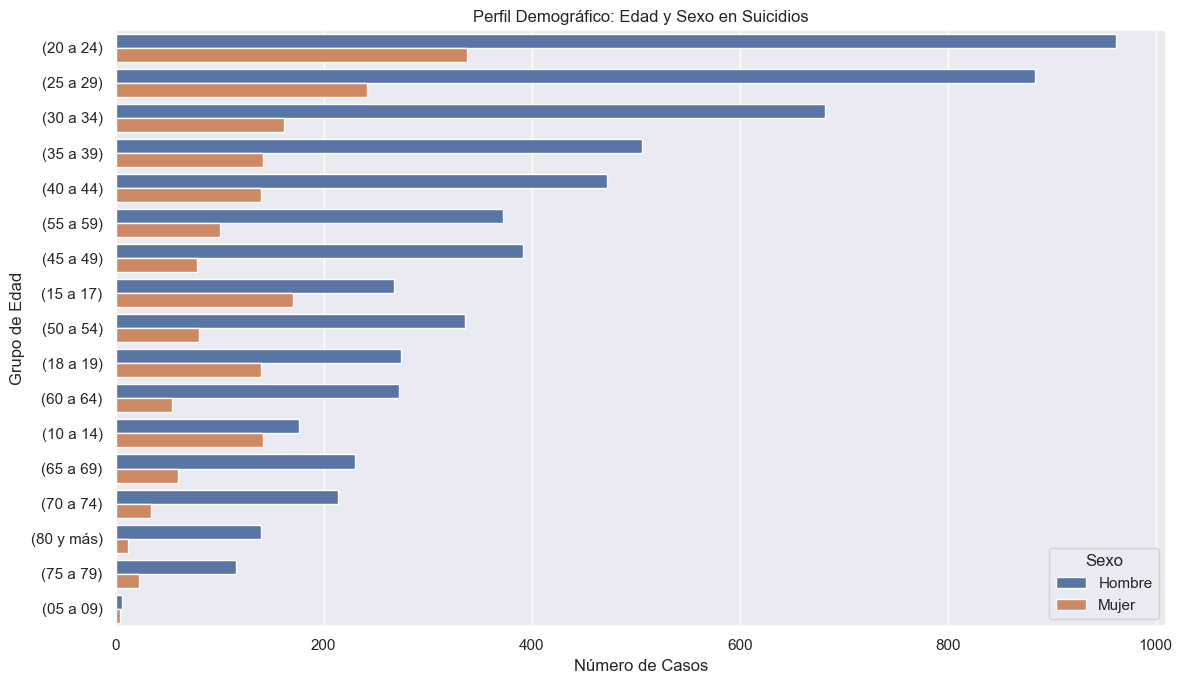

In [16]:
# ¿Mismo grupo etario? ¿Mismo sexo predominante?
col_edad = 'grupo_de_edad_quinquenal_'
col_sexo = 'sexo_de_la_victima'

plt.figure(figsize=(12,7))
orden_edad = df_suicidio[col_edad].value_counts().index
sns.countplot(data=df_suicidio, y=col_edad, hue=col_sexo, order=orden_edad)
plt.title('Perfil Demográfico: Edad y Sexo en Suicidios')
plt.xlabel('Número de Casos')
plt.ylabel('Grupo de Edad')
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

In [22]:
print(df_sui_limpio[col_loc].value_counts().head(15))
print('\nValores que contienen Bogot:')
print(df_suicidio[col_loc].value_counts().head(5))

localidad_del_hecho
Kennedy                  479
Suba                     452
Ciudad Bolívar           402
Engativá                 374
Usaquén                  355
Bosa                     326
San Cristóbal            245
Usme                     206
Rafael Uribe Uribe       176
Fontibón                 162
Chapinero                158
Localidad Desconocida    118
Puente Aranda            115
Santa Fe                 113
Tunjuelito               113
Name: count, dtype: int64

Valores que contienen Bogot:
localidad_del_hecho
Bogotá            4111
Kennedy            479
Suba               452
Ciudad Bolívar     402
Engativá           374
Name: count, dtype: int64


## ⚠️ Causas
**¿Qué razones o motivos de suicidio aparecen más?**

C:\Users\Latitude\AppData\Local\Temp\ipykernel_24024\2537179449.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=razones.values, y=razones.index, palette='flare')


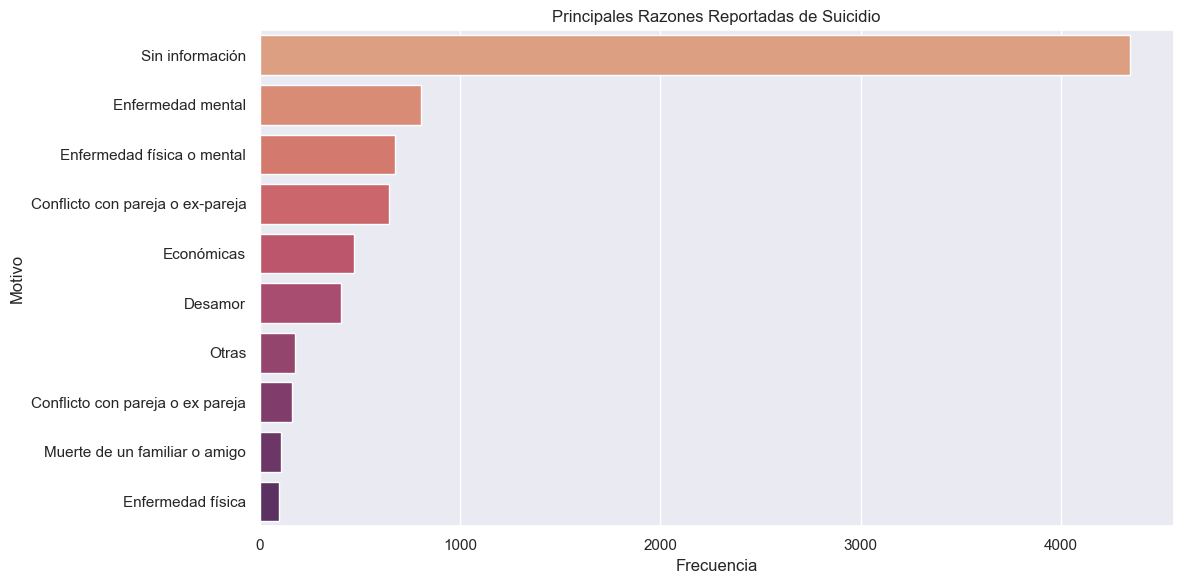

In [17]:
# ¿Qué razones o motivos de suicidio aparecen más?
col_razon = 'razon_del_suicidio'

razones = df_suicidio[col_razon].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=razones.values, y=razones.index, palette='flare')
plt.title('Principales Razones Reportadas de Suicidio')
plt.xlabel('Frecuencia')
plt.ylabel('Motivo')
plt.tight_layout()
plt.show()